# Dataset Exploration: AG News for Federated Personalized PEFT

### Research Description

Foundation models are too large to fine-tune on edge devices, so we use LoRA to restrict updates to a tiny low-rank subspace. However, a single global LoRA fails under Non-IID user data. Our approach adds client-specific weight-masking inside the LoRA module: each user discovers and trains only a sparse subnetwork (a personalized “lottery ticket”) within the shared LoRA. This yields a global collaborative core while giving every client their own sparse personalized identity - all without ever uploading private data or full adapter weights.

**Dataset**: AG News (4-class news topic classification)  


**Why AG News?**  
- Provides clear "personal identities" (clients can be World-news readers, Sports fans, Business professionals, or Sci/Tech enthusiasts).  
- Lightweight text dataset -> perfect for fast experiments on Kaggle T4.  
- Standard benchmark in recent FL + PEFT papers.  
- No custom annotations required (pre-labeled).

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import numpy as np
from wordcloud import WordCloud

print("Libraries loaded successfully")

Libraries loaded successfully


### Dataset Source
AG News: https://huggingface.co/datasets/fancyzhx/ag_news  
(This is the standard 4-class news topic classification benchmark used in FL and PEFT research.)

### Dataset Statistics
- **Number of classes**: 4 (World, Sports, Business, Sci/Tech)
- **Train split**: 120,000 examples
- **Test split**: 7,600 examples
- **Each sample**: Short news article (title + description) + label
- **No custom annotations** needed – fully pre-labeled

In [8]:
dataset = load_dataset("ag_news")
train = dataset['train']
test = dataset['test']

# summary table
stats = {
    "Split": ["Train", "Test"],
    "Samples": [len(train), len(test)],
    "Classes": [4, 4],
    "Class Names": [train.features['label'].names, train.features['label'].names]
}

df_stats = pd.DataFrame(stats)
print("📊 Dataset Overview")
display(df_stats)

print(f"\nClass names: {train.features['label'].names}")

📊 Dataset Overview


,Split,Samples,Classes,Class Names
0,Train,120000,4,"[World, Sports, Business, Sci/Tech]"
1,Test,7600,4,"[World, Sports, Business, Sci/Tech]"



Class names: ['World', 'Sports', 'Business', 'Sci/Tech']


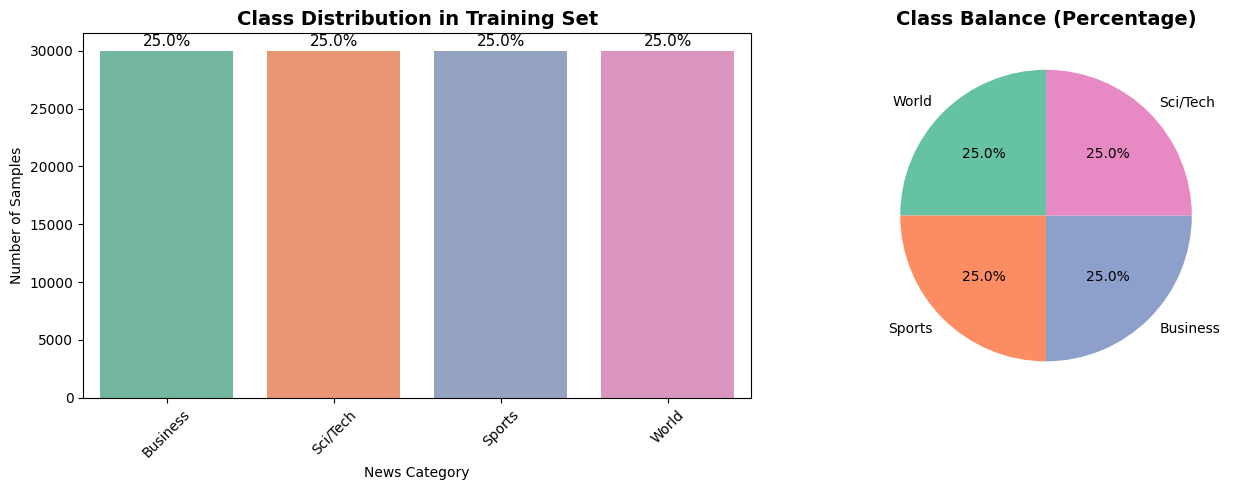

In [12]:
class_names = train.features['label'].names
train_labels = train['label']

plt.figure(figsize=(14, 5))

# Bar chart 
plt.subplot(1, 2, 1)
ax = sns.countplot(x=[class_names[l] for l in train_labels], 
                   palette="Set2", hue = [class_names[l] for l in train_labels], legend = False)
plt.title("Class Distribution in Training Set", fontsize=14, fontweight='bold')
plt.xlabel("News Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

# Add percentages on top of bars
total = len(train_labels)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, 
                (p.get_x() + p.get_width()/2., p.get_height() + 800),
                ha='center', va='center', fontsize=11)

# Pie chart
counts = [sum(1 for lbl in train_labels if lbl == i) for i in range(4)]
plt.subplot(1, 2, 2)
plt.pie(counts, 
        labels=class_names, 
        autopct='%1.1f%%',
        colors=sns.color_palette("Set2"), 
        startangle=90)
plt.title("Class Balance (Percentage)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

📏 Text Length Statistics (words per article)


,count,mean,std,min,25%,50%,75%,max
World,30000.0,38.9,10.3,11.0,33.0,39.0,44.0,145.0
Sports,30000.0,37.8,8.9,8.0,32.0,37.0,42.0,151.0
Business,30000.0,37.5,8.1,8.0,32.0,37.0,42.0,134.0
Sci/Tech,30000.0,37.2,12.4,8.0,30.0,36.0,42.0,177.0


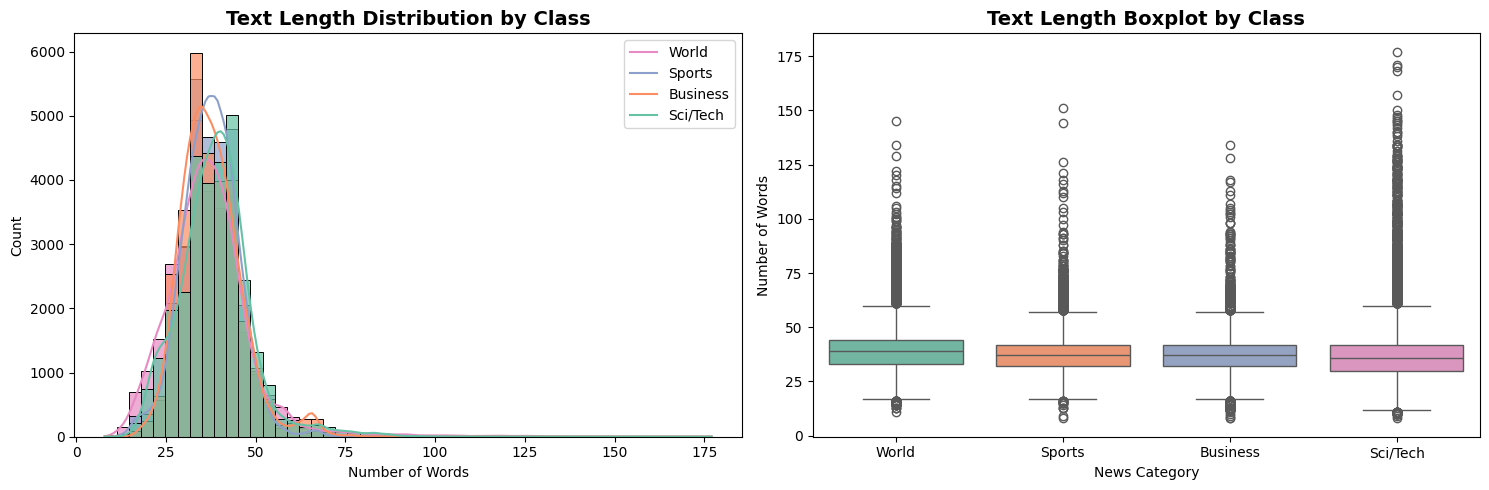

In [14]:
# Calculate text length in words
train_df = pd.DataFrame(train)
train_df['text_length'] = train_df['text'].apply(lambda x: len(x.split()))

# Summary statistics table per class
length_stats = train_df.groupby('label')['text_length'].describe().round(1)
length_stats.index = class_names
print("📏 Text Length Statistics (words per article)")
display(length_stats)

# Visualizations
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=train_df, x='text_length', hue='label', 
             bins=50, kde=True, palette="Set2", alpha=0.7)
plt.title("Text Length Distribution by Class", fontsize=14, fontweight='bold')
plt.xlabel("Number of Words")
plt.legend(class_names)

plt.subplot(1, 2, 2)
sns.boxplot(x='label', y='text_length', data=train_df, palette="Set2", hue = 'label', legend=False)
plt.title("Text Length Boxplot by Class", fontsize=14, fontweight='bold')
plt.xticks(ticks=range(4), labels=class_names)
plt.xlabel("News Category")
plt.ylabel("Number of Words")

plt.tight_layout()
plt.show()

In [19]:
print("📝 Sample Articles (5 random examples)")
samples = train_df.sample(5, random_state=42).copy()
samples['Class'] = samples['label'].map(lambda x: class_names[x])
samples = samples[['Class', 'text']]
samples['text'] = samples['text']
display(samples.style.set_properties(**{'text-align': 'left'}))

📝 Sample Articles (5 random examples)


,Class,text
71787,Business,"BBC set for major shake-up, claims newspaper London - The British Broadcasting Corporation, the world #39;s biggest public broadcaster, is to cut almost a quarter of its 28 000-strong workforce, in the biggest shake-up in its 82-year history, The Times newspaper in London said on Monday."
67218,Business,Marsh averts cash crunch Embattled insurance broker #39;s banks agree to waive clause that may have prevented access to credit. NEW YORK (Reuters) - Marsh amp; McLennan Cos.
54066,Sports,"Jeter, Yankees Look to Take Control (AP) AP - Derek Jeter turned a season that started with a terrible slump into one of the best in his accomplished 10-year career."
7168,Sci/Tech,"Flying the Sun to Safety When the Genesis capsule comes back to Earth with its samples of the sun, helicopter pilots will be waiting for it, ready to snag it out of the sky."
29618,Business,"Stocks Seen Flat as Nortel and Oil Weigh NEW YORK (Reuters) - U.S. stocks were set to open near unchanged on Thursday after a warning from technology bellwether Nortel Networks Corp. <A HREF=""http://www.investor.reuters.com/FullQuote.aspx?ticker=NT.N target=/stocks/quickinfo/fullquote"">NT.N</A> dimmed hopes, while stubbornly high oil prices also weighed on sentiment."


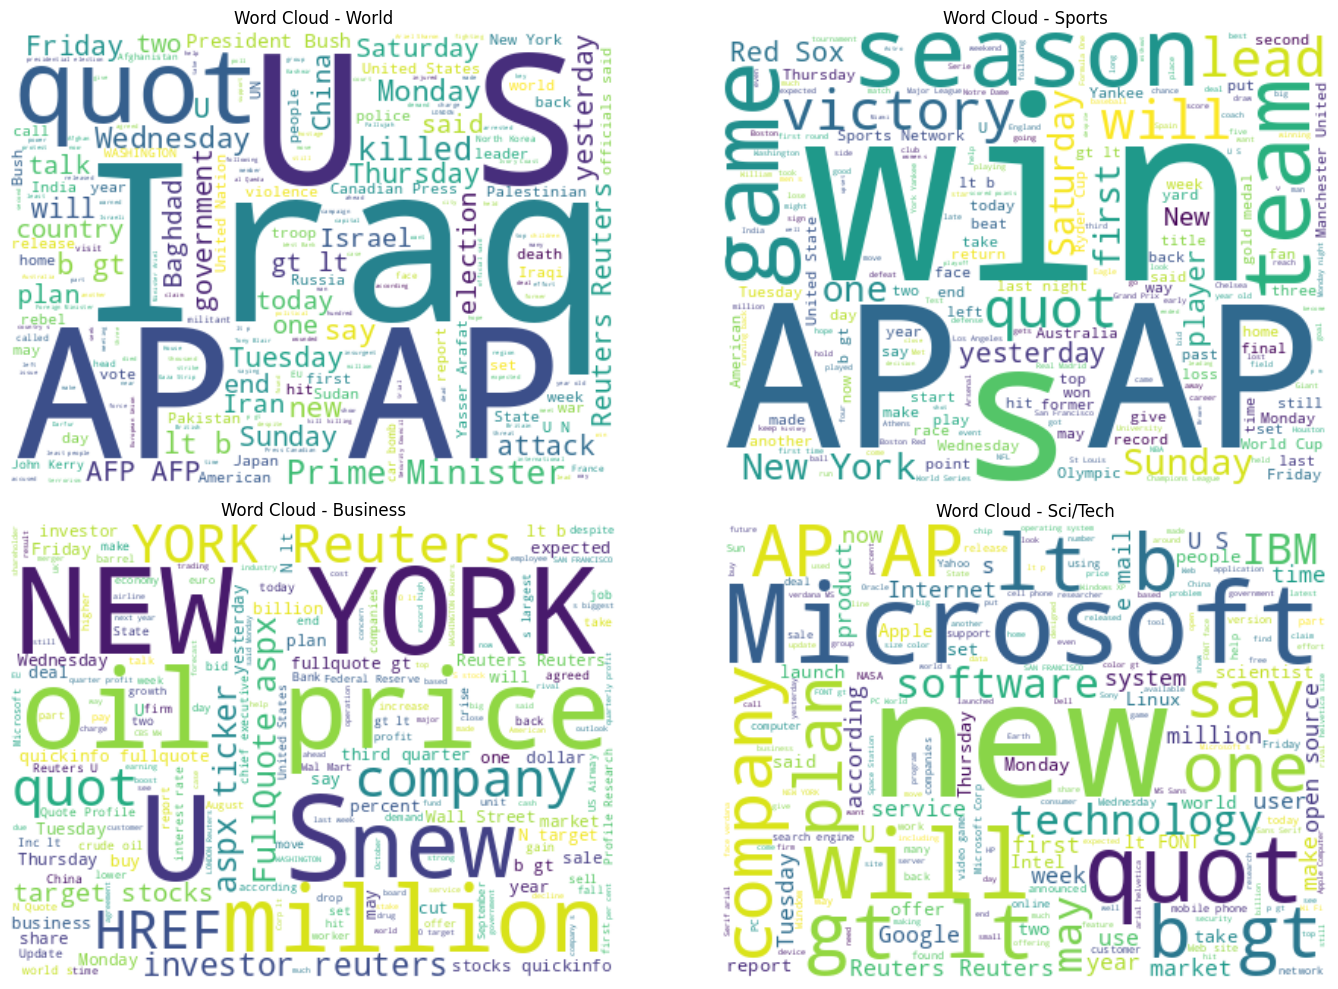

In [18]:
# Word clouds (one per class)
plt.figure(figsize=(15, 10))
for i, class_name in enumerate(class_names):
    text = " ".join([example['text'] for example in train if example['label'] == i])
    wordcloud = WordCloud(width=400, height=300, background_color='white').generate(text)
    
    plt.subplot(2, 2, i+1)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Word Cloud - {class_name}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Planned Non-IID Simulation for Federated Setting

We will simulate realistic client heterogeneity using the 4 classes as "personal identities":

- Client 1: Mostly **World** news (international user)
- Client 2: Mostly **Sports** news (sports fan)
- Client 3: Mostly **Business** news (finance professional)
- Client 4: Mostly **Sci/Tech** news (tech enthusiast)

This creates strong domain shift, exactly where local adapters + weight-masking will shine for personalization.

### Conclusion

We have fully explored the AG News dataset:
- 4 classes with clear topic-based identities
- Train/test splits documented
- Sample articles shown
- Visualizations (class distribution, length histogram, word clouds) created
- No custom annotations required

The dataset is well understood and ready for federated PEFT experiments with personalized local adapters and weight-masking.